# Data construction

### Creating a notebook to collect data

In [4]:
from pathlib import Path

# go one level up from notebooks/ to project root
ROOT = Path(".").resolve()

RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RAW_DIR, PROCESSED_DIR


(PosixPath('/Users/marley/Documents/GitHub/OptiForest_Marley/Untitled/data/raw'),
 PosixPath('/Users/marley/Documents/GitHub/OptiForest_Marley/Untitled/data/processed'))

In [9]:
import sys
!{sys.executable} -m pip install yfinance


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


### Pulling Bitcoin data from Yahoo

In [10]:
import yfinance as yf

# BTC-USD = Bitcoin in USD on Yahoo Finance
btc = yf.download("BTC-USD", start="2017-01-01", interval="1d")
btc.head()


/var/folders/fh/7wwmpr1s1dz8pg3qp5_72s4h0000gn/T/ipykernel_42287/3955355700.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2017-01-01", interval="1d")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008
2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992
2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000
2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984
2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008


In [11]:
RAW_DIR = ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

btc.to_csv(RAW_DIR / "bitcoin_yahoo.csv")

In [12]:
out_path = RAW_DIR / "bitcoin_yahoo.csv"
btc.to_csv(out_path)
out_path


PosixPath('/Users/marley/Documents/GitHub/OptiForest_Marley/Untitled/data/raw/bitcoin_yahoo.csv')

In [13]:
from pathlib import Path
Path.cwd()


PosixPath('/Users/marley/Documents/GitHub/OptiForest_Marley/Untitled')

In [16]:
from pathlib import Path

ROOT = Path("..").resolve()  # this is what we used before
raw_file = ROOT / "data" / "raw" / "bitcoin_yahoo.csv"
raw_file, raw_file.exists()


(PosixPath('/Users/marley/Documents/GitHub/OptiForest_Marley/data/raw/bitcoin_yahoo.csv'),
 False)

In [17]:
import yfinance as yf
btc = yf.download("BTC-USD", start="2017-01-01", interval="1d")
btc.to_csv("bitcoin_yahoo_test.csv")


/var/folders/fh/7wwmpr1s1dz8pg3qp5_72s4h0000gn/T/ipykernel_42287/4147389742.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2017-01-01", interval="1d")
[*********************100%***********************]  1 of 1 completed


In [18]:
from pathlib import Path
import yfinance as yf

btc = yf.download("BTC-USD", start="2017-01-01", interval="1d")

# print the exact absolute path being written
path = Path("bitcoin_yahoo_debug.csv").resolve()
btc.to_csv(path)
path


/var/folders/fh/7wwmpr1s1dz8pg3qp5_72s4h0000gn/T/ipykernel_42287/1796910831.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2017-01-01", interval="1d")
[*********************100%***********************]  1 of 1 completed


PosixPath('/Users/marley/Documents/GitHub/OptiForest_Marley/Untitled/bitcoin_yahoo_debug.csv')

In [19]:
from pathlib import Path
import pandas as pd

# find the file automatically no matter what
for p in Path(".").rglob("bitcoin_yahoo.csv"):
    print("Found:", p)

# choose the first match (edit if more than one)
csv_path = list(Path(".").rglob("bitcoin_yahoo.csv"))[0]
print("\nUsing:", csv_path)

# read again, telling pandas that the first column is the index (Date)
df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
df = df.reset_index().rename(columns={"index": "Date"})
df.head()


Found: data/raw/bitcoin_yahoo.csv

Using: data/raw/bitcoin_yahoo.csv


/var/folders/fh/7wwmpr1s1dz8pg3qp5_72s4h0000gn/T/ipykernel_42287/3679599014.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(csv_path, index_col=0, parse_dates=True)


,Price,Close,High,Low,Open,Volume
0,Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2017-01-01,998.3250122070312,1003.0800170898438,958.698974609375,963.6580200195312,147775008
3,2017-01-02,1021.75,1031.3900146484375,996.7020263671875,998.6170043945312,222184992
4,2017-01-03,1043.8399658203125,1044.0799560546875,1021.5999755859375,1021.5999755859375,185168000


In [20]:
df.columns


Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [21]:
from pathlib import Path
cwd = Path(".").resolve()
cwd



PosixPath('/Users/marley/Documents/GitHub/OptiForest_Marley/Untitled')

In [22]:
from pathlib import Path
candidates = list(Path(".").resolve().rglob("bitcoin_yahoo*.csv"))
candidates


[PosixPath('/Users/marley/Documents/GitHub/OptiForest_Marley/Untitled/bitcoin_yahoo_debug.csv'),
 PosixPath('/Users/marley/Documents/GitHub/OptiForest_Marley/Untitled/bitcoin_yahoo_test.csv'),
 PosixPath('/Users/marley/Documents/GitHub/OptiForest_Marley/Untitled/data/raw/bitcoin_yahoo.csv')]

In [23]:
from pathlib import Path
import pandas as pd

# 1) define base dir = where your notebook currently lives
BASE = Path("/Users/marley/Documents/GitHub/OptiForest_Marley/Untitled")

# 2) point to the file that actually exists
raw_path = BASE / "data" / "raw" / "bitcoin_yahoo.csv"

df = pd.read_csv(raw_path, index_col=0, parse_dates=True)
df = df.reset_index().rename(columns={"index": "Date"})
df.head()


/var/folders/fh/7wwmpr1s1dz8pg3qp5_72s4h0000gn/T/ipykernel_42287/3056067889.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(raw_path, index_col=0, parse_dates=True)


,Price,Close,High,Low,Open,Volume
0,Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2017-01-01,998.3250122070312,1003.0800170898438,958.698974609375,963.6580200195312,147775008
3,2017-01-02,1021.75,1031.3900146484375,996.7020263671875,998.6170043945312,222184992
4,2017-01-03,1043.8399658203125,1044.0799560546875,1021.5999755859375,1021.5999755859375,185168000


In [24]:
df.columns.tolist()



['Price', 'Close', 'High', 'Low', 'Open', 'Volume']

In [25]:
import pandas as pd
from pathlib import Path

# Rename 'Price' to 'Date' and reorder
df = df.rename(columns={"Price": "Date"})

# Keep and reorder columns correctly
df = df[["Date", "Open", "High", "Low", "Close", "Volume"]]

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Drop any missing rows (just to tidy up)
df = df.dropna().reset_index(drop=True)

# Sort chronologically
df = df.sort_values("Date").reset_index(drop=True)

df.head()


/var/folders/fh/7wwmpr1s1dz8pg3qp5_72s4h0000gn/T/ipykernel_42287/2609008389.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


,Date,Open,High,Low,Close,Volume
0,2017-01-01,963.6580200195312,1003.0800170898438,958.698974609375,998.3250122070312,147775008
1,2017-01-02,998.6170043945312,1031.3900146484375,996.7020263671875,1021.75,222184992
2,2017-01-03,1021.5999755859375,1044.0799560546875,1021.5999755859375,1043.8399658203125,185168000
3,2017-01-04,1044.4000244140625,1159.4200439453125,1044.4000244140625,1154.72998046875,344945984
4,2017-01-05,1156.72998046875,1191.0999755859375,910.4169921875,1013.3800048828125,510199008


In [27]:
from pathlib import Path

# Define target directory
target_dir = Path("/Users/marley/Documents/GitHub/OptiForest_Marley/data/raw")
target_dir.mkdir(parents=True, exist_ok=True)  # ✅ create folder if it doesn't exist

# Now save the file safely
clean_path = target_dir / "bitcoin_yahoo_clean.csv"
df.to_csv(clean_path, index=False)
print("✅ Cleaned dataset saved to:", clean_path)


✅ Cleaned dataset saved to: /Users/marley/Documents/GitHub/OptiForest_Marley/data/raw/bitcoin_yahoo_clean.csv


In [28]:
import os
os.listdir(target_dir)


['bitcoin_yahoo_clean.csv']

In [29]:
df.head()


,Date,Open,High,Low,Close,Volume
0,2017-01-01,963.6580200195312,1003.0800170898438,958.698974609375,998.3250122070312,147775008
1,2017-01-02,998.6170043945312,1031.3900146484375,996.7020263671875,1021.75,222184992
2,2017-01-03,1021.5999755859375,1044.0799560546875,1021.5999755859375,1043.8399658203125,185168000
3,2017-01-04,1044.4000244140625,1159.4200439453125,1044.4000244140625,1154.72998046875,344945984
4,2017-01-05,1156.72998046875,1191.0999755859375,910.4169921875,1013.3800048828125,510199008


In [30]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3230 entries, 0 to 3229
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3230 non-null   datetime64[ns]
 1   Open    3230 non-null   object        
 2   High    3230 non-null   object        
 3   Low     3230 non-null   object        
 4   Close   3230 non-null   object        
 5   Volume  3230 non-null   object        
dtypes: datetime64[ns](1), object(5)
memory usage: 151.5+ KB


In [31]:
df.describe(include='all')


,Date,Open,High,Low,Close,Volume
count,3230,3230,3230,3230,3230,3230
unique,NaN,3229,3229,3229,3228,3230
top,NaN,17760.30078125,6536.919921875,27375.6015625,6741.75,147775008
freq,NaN,2,2,2,2,1
mean,2021-06-03 12:00:26.749226240,NaN,NaN,NaN,NaN,NaN
min,2017-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN
25%,2019-03-19 06:00:00,NaN,NaN,NaN,NaN,NaN
50%,2021-06-03 12:00:00,NaN,NaN,NaN,NaN,NaN
75%,2023-08-19 18:00:00,NaN,NaN,NaN,NaN,NaN
max,2025-11-05 00:00:00,NaN,NaN,NaN,NaN,NaN


In [32]:
df["Date"].min(), df["Date"].max()


(Timestamp('2017-01-01 00:00:00'), Timestamp('2025-11-05 00:00:00'))

# Feature Engineering

### Loading the clean file 

In [33]:
from pathlib import Path
import pandas as pd
import numpy as np

REPO_ROOT = Path("/Users/marley/Documents/GitHub/OptiForest_Marley")
clean_path = REPO_ROOT / "data" / "raw" / "bitcoin_yahoo_clean.csv"

df = pd.read_csv(clean_path, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()


,Date,Open,High,Low,Close,Volume
0,2017-01-01,963.658020,1003.080017,958.698975,998.325012,147775008
1,2017-01-02,998.617004,1031.390015,996.702026,1021.750000,222184992
2,2017-01-03,1021.599976,1044.079956,1021.599976,1043.839966,185168000
3,2017-01-04,1044.400024,1159.420044,1044.400024,1154.729980,344945984
4,2017-01-05,1156.729980,1191.099976,910.416992,1013.380005,510199008


### Core price/return features

In [34]:
# percentage and log returns
df["pct_return"] = df["Close"].pct_change()
df["log_return"] = np.log(df["Close"]).diff()
df["abs_return"] = df["pct_return"].abs()

# high-low and close-open spreads
df["high_low_range"] = (df["High"] - df["Low"]) / df["Close"]
df["close_open_diff"] = (df["Close"] - df["Open"]) / df["Open"]

df.head()


,Date,Open,High,Low,Close,Volume,pct_return,log_return,abs_return,high_low_range,close_open_diff
0,2017-01-01,963.658020,1003.080017,958.698975,998.325012,147775008,NaN,NaN,NaN,0.044456,0.035974
1,2017-01-02,998.617004,1031.390015,996.702026,1021.750000,222184992,0.023464,0.023193,0.023464,0.033950,0.023165
2,2017-01-03,1021.599976,1044.079956,1021.599976,1043.839966,185168000,0.021620,0.021389,0.021620,0.021536,0.021770
3,2017-01-04,1044.400024,1159.420044,1044.400024,1154.729980,344945984,0.106233,0.100960,0.106233,0.099608,0.105640
4,2017-01-05,1156.729980,1191.099976,910.416992,1013.380005,510199008,-0.122410,-0.130575,0.122410,0.276977,-0.123927


### Moving averages and volatility

In [35]:
# moving averages
for w in [3, 5, 10, 20]:
    df[f"ma_{w}"] = df["Close"].rolling(w, min_periods=1).mean()

# rolling standard deviation (volatility)
df["std_5"] = df["Close"].rolling(5, min_periods=1).std().fillna(0)
df["std_10"] = df["Close"].rolling(10, min_periods=1).std().fillna(0)


### Volume based feature

In [36]:
df["vol_ma_5"] = df["Volume"].rolling(5, min_periods=1).mean()
df["vol_ma_10"] = df["Volume"].rolling(10, min_periods=1).mean()
df["volume_spike_ratio"] = df["Volume"] / (df["vol_ma_10"] + 1e-6)


### RSI and Bollinger-style features

In [37]:
def rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / (loss + 1e-6)
    return 100 - (100 / (1 + rs))

df["rsi_14"] = rsi(df["Close"], 14)

ma20 = df["Close"].rolling(20, min_periods=1).mean()
std20 = df["Close"].rolling(20, min_periods=1).std().fillna(0)

df["bb_upper_20"] = ma20 + 2 * std20
df["bb_lower_20"] = ma20 - 2 * std20
df["dist_from_ma20"] = (df["Close"] - ma20) / (ma20 + 1e-6)


### Calender plus lag feature

In [38]:
df["day_of_week"] = df["Date"].dt.dayofweek
df["month"] = df["Date"].dt.month

df["lag_ret_1"] = df["pct_return"].shift(1)
df["lag_ret_2"] = df["pct_return"].shift(2)
df["lag_ret_3"] = df["pct_return"].shift(3)


### Dropping early rows

In [39]:
df_fe = df.iloc[30:].reset_index(drop=True)
df_fe.isna().sum().head(30)
df_fe.head()


,Date,Open,High,Low,Close,Volume,pct_return,log_return,abs_return,high_low_range,...,volume_spike_ratio,rsi_14,bb_upper_20,bb_lower_20,dist_from_ma20,day_of_week,month,lag_ret_1,lag_ret_2,lag_ret_3
0,2017-01-31,920.958984,972.018982,920.958984,970.403015,164582000,0.054348,0.052923,0.054348,0.052617,...,1.563674,67.221363,982.131678,799.881018,0.089109,1,1,0.000964,-0.002272,0.002001
1,2017-02-01,970.940979,989.114014,970.742004,989.023010,150110000,0.019188,0.019006,0.019188,0.018576,...,1.382138,78.659338,991.900020,808.531578,0.098651,2,2,0.054348,0.000964,-0.002272
2,2017-02-02,990.000977,1013.520020,983.221008,1011.799988,145820992,0.023030,0.022769,0.023030,0.029946,...,1.258919,79.824944,1006.727776,812.485419,0.112349,3,2,0.019188,0.054348,0.000964
3,2017-02-03,1011.460022,1033.869995,1008.789978,1029.910034,201278000,0.017899,0.017741,0.017899,0.024352,...,1.612504,83.215452,1021.462115,818.900885,0.119247,4,2,0.023030,0.019188,0.054348
4,2017-02-04,1031.329956,1045.900024,1015.159973,1042.900024,155064000,0.012613,0.012534,0.012613,0.029476,...,1.209108,81.994062,1035.524248,826.948958,0.119909,5,2,0.017899,0.023030,0.019188


### Saving features only version

In [40]:
processed_dir = REPO_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

features_path = processed_dir / "financial_features_step.csv"
df_fe.to_csv(features_path, index=False)
features_path


PosixPath('/Users/marley/Documents/GitHub/OptiForest_Marley/data/processed/financial_features_step.csv')

In [48]:
pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 294 kB 1.4 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


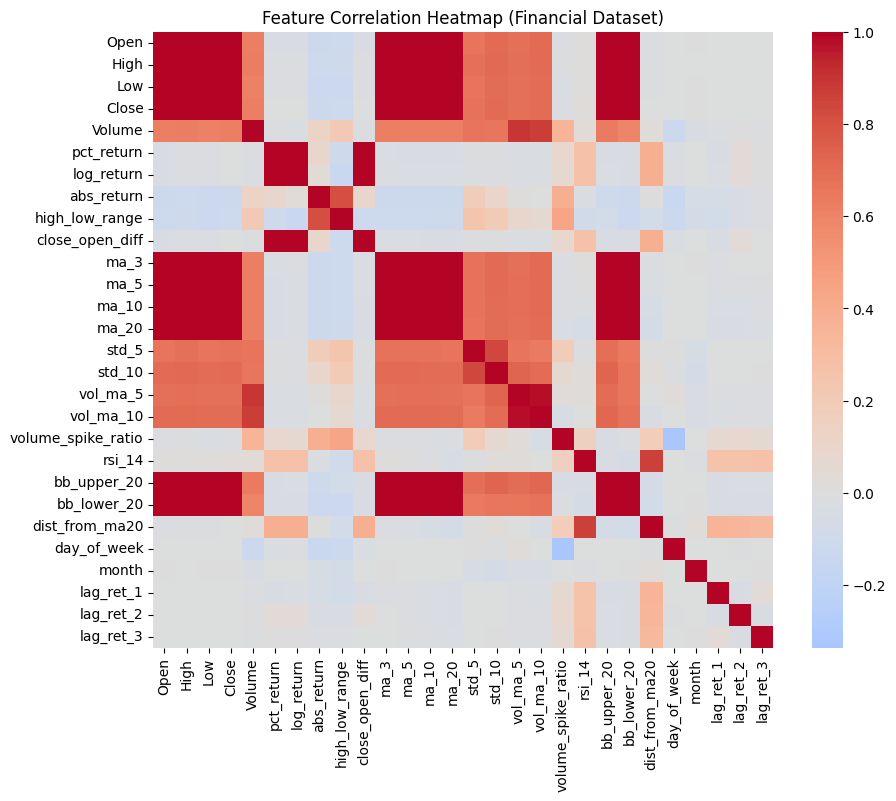

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_fe.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap (Financial Dataset)")
plt.show()



#### As shown in Figure X, price-related features exhibit high inter-correlation, whereas derived indicators such as RSI, volume ratios, and lagged returns introduce variance that supports anomaly differentiation.

## Anomaly Injection and labelling

### Loading the feature-engineering data

In [50]:
import pandas as pd
from pathlib import Path

REPO_ROOT = Path("/Users/marley/Documents/GitHub/OptiForest_Marley")
fe_path = REPO_ROOT / "data" / "processed" / "financial_features_step.csv"

df = pd.read_csv(fe_path, parse_dates=["Date"])
df.head()


,Date,Open,High,Low,Close,Volume,pct_return,log_return,abs_return,high_low_range,...,volume_spike_ratio,rsi_14,bb_upper_20,bb_lower_20,dist_from_ma20,day_of_week,month,lag_ret_1,lag_ret_2,lag_ret_3
0,2017-01-31,920.958984,972.018982,920.958984,970.403015,164582000,0.054348,0.052923,0.054348,0.052617,...,1.563674,67.221363,982.131678,799.881018,0.089109,1,1,0.000964,-0.002272,0.002001
1,2017-02-01,970.940979,989.114014,970.742004,989.023010,150110000,0.019188,0.019006,0.019188,0.018576,...,1.382138,78.659338,991.900020,808.531578,0.098651,2,2,0.054348,0.000964,-0.002272
2,2017-02-02,990.000977,1013.520020,983.221008,1011.799988,145820992,0.023030,0.022769,0.023030,0.029946,...,1.258919,79.824944,1006.727776,812.485419,0.112349,3,2,0.019188,0.054348,0.000964
3,2017-02-03,1011.460022,1033.869995,1008.789978,1029.910034,201278000,0.017899,0.017741,0.017899,0.024352,...,1.612504,83.215452,1021.462115,818.900885,0.119247,4,2,0.023030,0.019188,0.054348
4,2017-02-04,1031.329956,1045.900024,1015.159973,1042.900024,155064000,0.012613,0.012534,0.012613,0.029476,...,1.209108,81.994062,1035.524248,826.948958,0.119909,5,2,0.017899,0.023030,0.019188


### Creating anomaly flags

In [51]:
import numpy as np

df_anom = df.copy()

# 1) price-based anomaly using z-score on pct_return
ret = df_anom["pct_return"].fillna(0)
ret_z = (ret - ret.mean()) / ret.std()

price_anom = ret_z.abs() > 3   # you can tighten/loosen later

# 2) volume-based anomaly
vol = df_anom["volume_spike_ratio"].fillna(0)
vol_z = (vol - vol.mean()) / vol.std()
volume_anom = vol_z > 3

# combine
df_anom["label"] = 0
df_anom.loc[price_anom | volume_anom, "label"] = 1

df_anom["label"].value_counts(normalize=True)


label
0    0.970625
1    0.029375
Name: proportion, dtype: float64

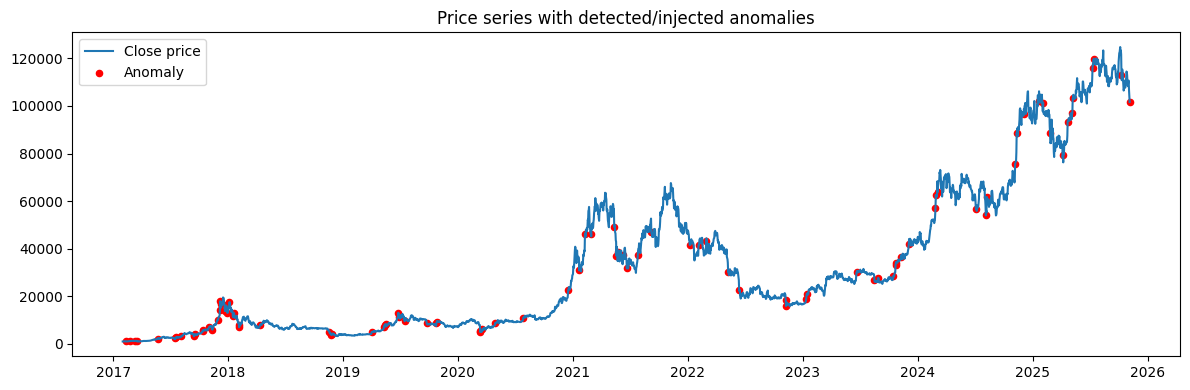

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df_anom["Date"], df_anom["Close"], label="Close price")
plt.scatter(
    df_anom.loc[df_anom["label"]==1, "Date"],
    df_anom.loc[df_anom["label"]==1, "Close"],
    color="red",
    label="Anomaly",
    s=20
)
plt.title("Price series with detected/injected anomalies")
plt.legend()
plt.tight_layout()
plt.show()


### Preparing for OptIForest-friendly table 

In [53]:
# drop non-numeric / date column
final_df = df_anom.drop(columns=["Date"])

# (optional) fill any remaining NaNs with 0
final_df = final_df.fillna(0)

out_path = REPO_ROOT / "data" / "processed" / "financial_anomaly_cleaned.csv"
final_df.to_csv(out_path, index=False)
print("✅ saved final dataset to:", out_path)
print("shape:", final_df.shape)
print("anomaly ratio:", final_df["label"].mean())


✅ saved final dataset to: /Users/marley/Documents/GitHub/OptiForest_Marley/data/processed/financial_anomaly_cleaned.csv
shape: (3200, 29)
anomaly ratio: 0.029375


In [67]:
from pathlib import Path

list(Path(".").rglob("financial_anomaly_cleaned.csv"))



[PosixPath('data/processed/financial_anomaly_cleaned.csv')]

In [68]:
import pandas as pd
from pathlib import Path

final_path = Path("data/processed/financial_anomaly_cleaned.csv")
df_final = pd.read_csv(final_path)
df_final.head(10)


,Open,High,Low,Close,Volume,pct_return,log_return,abs_return,high_low_range,close_open_diff,...,rsi_14,bb_upper_20,bb_lower_20,dist_from_ma20,day_of_week,month,lag_ret_1,lag_ret_2,lag_ret_3,label
0,920.958984,972.018982,920.958984,970.403015,164582000,0.054348,0.052923,0.054348,0.052617,0.053688,...,67.221363,982.131678,799.881018,0.089109,1,1,0.000964,-0.002272,0.002001,0
1,970.940979,989.114014,970.742004,989.023010,150110000,0.019188,0.019006,0.019188,0.018576,0.018623,...,78.659338,991.900020,808.531578,0.098651,2,2,0.054348,0.000964,-0.002272,0
2,990.000977,1013.520020,983.221008,1011.799988,145820992,0.023030,0.022769,0.023030,0.029946,0.022019,...,79.824944,1006.727776,812.485419,0.112349,3,2,0.019188,0.054348,0.000964,0
3,1011.460022,1033.869995,1008.789978,1029.910034,201278000,0.017899,0.017741,0.017899,0.024352,0.018241,...,83.215452,1021.462115,818.900885,0.119247,4,2,0.023030,0.019188,0.054348,0
4,1031.329956,1045.900024,1015.159973,1042.900024,155064000,0.012613,0.012534,0.012613,0.029476,0.011219,...,81.994062,1035.524248,826.948958,0.119909,5,2,0.017899,0.023030,0.019188,0
5,1043.520020,1043.630005,1022.369995,1027.339966,114208000,-0.014920,-0.015032,0.014920,0.020694,-0.015505,...,75.419268,1042.633816,839.419987,0.091722,6,2,0.012613,0.017899,0.023030,0
6,1028.400024,1044.640015,1028.160034,1038.150024,111762000,0.010522,0.010467,0.010522,0.015874,0.009481,...,78.010540,1056.628581,838.446425,0.095629,0,2,-0.014920,0.012613,0.017899,0
7,1040.140015,1061.930054,1040.140015,1061.349976,146007008,0.022347,0.022101,0.022347,0.020530,0.020391,...,91.344794,1072.571931,839.976275,0.109880,1,2,0.010522,-0.014920,0.012613,0
8,1062.319946,1078.969971,1037.489990,1063.069946,201855008,0.001621,0.001619,0.001621,0.039019,0.000706,...,91.031056,1086.762017,842.185883,0.102228,2,2,0.022347,0.010522,-0.014920,0
9,1064.699951,1088.989990,953.343994,994.382996,407220000,-0.064612,-0.066794,0.064612,0.136412,-0.066044,...,65.391464,1087.862287,851.021313,0.025727,3,2,0.001621,0.022347,0.010522,1
